In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
#
from Regions_functions_V2 import polygon_definition_data_S1, volumes_75m_bottom

# Test Nibi Run (2007, 2008, 2009 AND 2010)

In [2]:
path_sim = '/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/long_term_simulation.nc'
data_full = xr.open_dataset(path_sim)

In [3]:
data_2007 = data_full.isel(obs = slice(None, 4380))
data_2008 = data_full.isel(obs = slice(4381, 4387*2))
data_2009 = data_full.isel(obs = slice(4386*2 + 2, 4385*3))
data_2010 = data_full.isel(obs = slice(4385*3, 4384*4))

APR and MAY

In [4]:
data_2007_APR_MAY = data_2007.isel(obs = slice(1080, 1812))
data_2008_APR_MAY = data_2008.isel(obs = slice(1092, 1824))
data_2009_APR_MAY = data_2009.isel(obs = slice(1080, 1812))
data_2010_APR_MAY = data_2010.isel(obs = slice(1080, 1812))

In [5]:
counts_2007 = polygon_definition_data_S1(data_2007_APR_MAY)

In [6]:
counts_2008 = polygon_definition_data_S1(data_2008_APR_MAY)

In [7]:
counts_2009 = polygon_definition_data_S1(data_2009_APR_MAY)

In [8]:
counts_2010 = polygon_definition_data_S1(data_2010_APR_MAY)

Text(0.5, 1.0, '# Particles summed > 75 m depth')

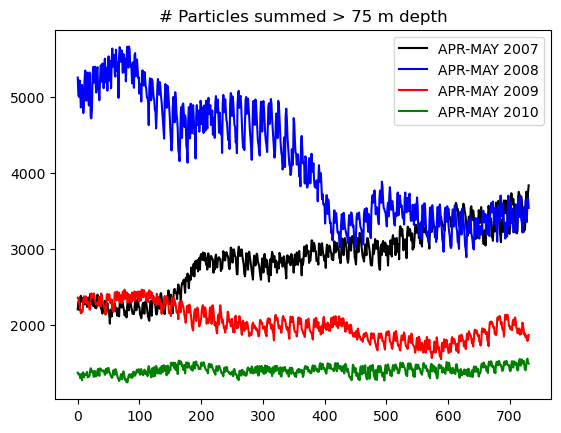

In [9]:
plt.plot(counts_2007.values, 'k', label = 'APR-MAY 2007')
plt.plot(counts_2008.values, 'b', label = 'APR-MAY 2008')
plt.plot(counts_2009.values, 'r', label = 'APR-MAY 2009')
plt.plot(counts_2010.values, 'g', label = 'APR-MAY 2010')
plt.legend()
plt.title('# Particles summed > 75 m depth')

In [10]:
print('Average 2007 APR-MAY: ', int(counts_2007.mean().iloc[0]))
print('Average 2008 APR-MAY: ', int(counts_2008.mean().iloc[0]))
print('Average 2009 APR-MAY: ', int(counts_2009.mean().iloc[0]))
print('Average 2010 APR-MAY: ', int(counts_2010.mean().iloc[0]))

Average 2007 APR-MAY:  2882
Average 2008 APR-MAY:  4157
Average 2009 APR-MAY:  2019
Average 2010 APR-MAY:  1411


/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


Text(0.5, 1.0, 'Mean # of Particles (APR-MAY)')

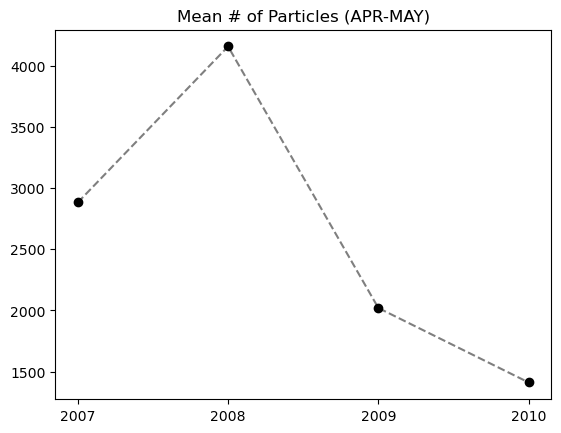

In [11]:
fig, ax = plt.subplots()
ax.scatter(['2007', '2008', '2009', '2010'], [counts_2007.mean(), counts_2008.mean(), counts_2009.mean(), counts_2010.mean()], c = 'k')
ax.plot(['2007', '2008', '2009', '2010'], [counts_2007.mean(), counts_2008.mean(), counts_2009.mean(), counts_2010.mean()], '--k', alpha = .5)
#
ax.set_title('Mean # of Particles (APR-MAY)')

In [12]:
apr_2007 = counts_2007.iloc[:359].sum().iloc[0]
may_2007 = counts_2007.iloc[359:].sum().iloc[0]

In [13]:
apr_2008 = counts_2008.iloc[:359].sum().iloc[0]
may_2008 = counts_2008.iloc[359:].sum().iloc[0]

In [14]:
apr_2009 = counts_2009.iloc[:359].sum().iloc[0]
may_2009 = counts_2009.iloc[359:].sum().iloc[0]

In [15]:
apr_2010 = counts_2010.iloc[:359].sum().iloc[0]
may_2010 = counts_2010.iloc[359:].sum().iloc[0]

Text(0.5, 1.0, 'Monthly Total Sum of Particles')

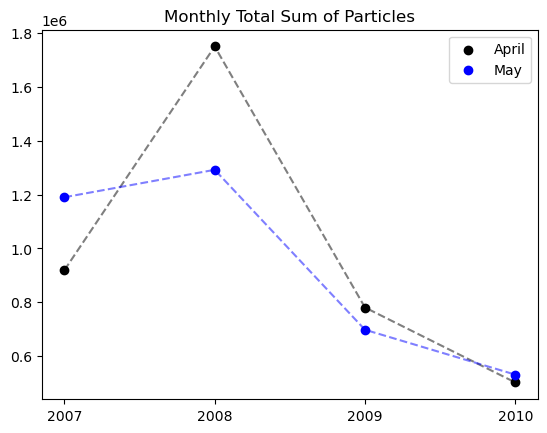

In [16]:
fig, ax = plt.subplots()
ax.scatter(['2007', '2008', '2009', '2010'], [apr_2007, apr_2008, apr_2009, apr_2010], c = 'k', label = 'April')
ax.plot(['2007', '2008', '2009', '2010'], [apr_2007, apr_2008, apr_2009, apr_2010], '--k', alpha = .5)
#
ax.scatter(['2007', '2008', '2009', '2010'], [may_2007, may_2008, may_2009, may_2010], c = 'b', label = 'May')
ax.plot(['2007', '2008', '2009', '2010'], [may_2007, may_2008, may_2009, may_2010], '--b', alpha = .5)
#
ax.legend()
ax.set_title('Monthly Total Sum of Particles')

In [17]:
print('Total Sum 2007 APR', apr_2007)
print('Total Sum 2007 MAY', may_2007)
#
print('Total Sum 2008 APR', apr_2008)
print('Total Sum 2008 MAY', may_2008)
#
print('Total Sum 2009 APR', apr_2009)
print('Total Sum 2009 MAY', may_2009)
#
print('Total Sum 2010 APR', apr_2010)
print('Total Sum 2010 MAY', may_2010)

Total Sum 2007 APR 919358
Total Sum 2007 MAY 1190455
Total Sum 2008 APR 1750766
Total Sum 2008 MAY 1292393
Total Sum 2009 APR 780619
Total Sum 2009 MAY 697917
Total Sum 2010 APR 501965
Total Sum 2010 MAY 531130


Volume S1

In [18]:
volumes_regions, regions_names = volumes_75m_bottom()

In [19]:
volumeS1 = volumes_regions[4]

In [20]:
print('Volume Region S1 > 75m: ', volumeS1, ' m3')

Volume Region S1 > 75m:  210309647844.0  m3


Text(0.5, 1.0, 'Monthly Total Sum of Particles')

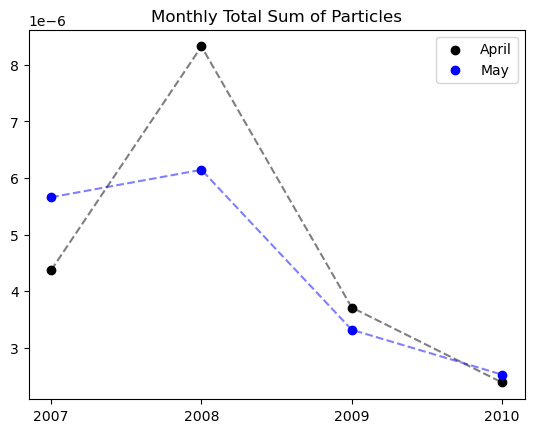

In [21]:
fig, ax = plt.subplots()
ax.scatter(['2007', '2008', '2009', '2010'], [apr_2007/volumeS1, apr_2008/volumeS1, apr_2009/volumeS1, apr_2010/volumeS1], c = 'k', label = 'April')
ax.plot(['2007', '2008', '2009', '2010'], [apr_2007/volumeS1, apr_2008/volumeS1, apr_2009/volumeS1, apr_2010/volumeS1], '--k', alpha = .5)
#
ax.scatter(['2007', '2008', '2009', '2010'], [may_2007/volumeS1, may_2008/volumeS1, may_2009/volumeS1, may_2010/volumeS1], c = 'b', label = 'May')
ax.plot(['2007', '2008', '2009', '2010'], [may_2007/volumeS1, may_2008/volumeS1, may_2009/volumeS1, may_2010/volumeS1], '--b', alpha = .5)
#
ax.legend()
ax.set_title('Monthly Total Sum of Particles')